# **DASK Operation**

**Version:** 1.0 | **Last updated:** 2026-08-11

**Author:** Asif Ashraf | **Author institution:** EarthScope Consortium

**Maintainer:** EarthScope OnRamp Team | **Maintainer's contact:** help@earthscope.org

**License:** CC-BY-4.0

---

### **Introduction**

This notebook teaches how to use `dask` in scaling up python code and data processing workflows to handle larger-than-memory datasets and leverage multiple cores. With the help of `dask`, you can easily scale a wide array of solutions and configure your project to use most of the available computational power. The best part is that you don’t need to rewrite your entire codebase, you just have to enable parallel computing with minimal modifications based on your use cases.

In this notebook we will examine how the structure of a problem determines whether—and how—it can be parallelized.

### **Learning objectives**

By the end of this notebook, you will be able to:

- identify independent and dependent tasks in a workflow;
- construct and inspect a real Dask task graph;
- choose suitable chunks and partitions for arrays and tables;
- use `dask.delayed` for a fixed workflow with known dependencies;
- use `dask.futures` for dynamic or interactive processing;
- distinguish between `compute()` and `persist()`; and

### **Table of Contents**

1. [Dask environment](#1-dask-environment)
2. [Workflow parallelization](#2-workflow-parallelization)
3. [Dask array (chunking)](#3-dask-array—chunking)
4. [Dask dataframe (partitioning)](#4-dask-dataFrame—partitioning)
5. [Dask delayed (building workflows)](#5-dask-delayed-building-workflows)
6. [Dask futures (dynamic processing)](#6-dask-futures-dynamic-processing)
7. [Compute vs Persist (Controlling execution)](#7-compute-vs-persist-controlling-execution)

---

### **1. Dask environment**


We will use a small local Dask cluster so that the exercises are portable and do not unnecessarily reserve GeoLab worker resources. The workflow code developed
here can later run on a Gateway cluster by changing only the client connection.

In [1]:
from dask.distributed import Client

client = Client(
    n_workers=2,
    threads_per_worker=2
)

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/8787/status,
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/8787/status,Workers: 2
Total threads: 4,Total memory: 3.63 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35979,Workers: 0
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35145,Total threads: 2
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/45529/status,Memory: 1.82 GiB
Nanny: tcp://127.0.0.1:38611,


The client widget reports the available workers, threads, and memory. It also provides a link to the Dask dashboard, where we can observe task execution, worker activity, and memory use.

Starting a client does not automatically make ordinary Python code parallel. The computation must still be expressed using a Dask collection, Delayed task, or Future.

**The Dask dashboard**

The link shown in the client widget above opens the Dask **dashboard**, a live browser-based view of everything the cluster is doing. It is the main tool for understanding *how* a computation runs, not just whether it finished. A few of the most useful panels:

- **Task Stream** &mdash; a timeline of individual tasks on each worker thread. Solid, tightly packed bars mean the workers are busy; large gaps or long data-transfer bars usually point to a bottleneck.
- **Progress** &mdash; colored bars showing how many tasks of each type are queued, in flight, and complete for the current computation.
- **Bytes Stored / Memory per Worker** &mdash; how much data each worker is holding, useful for spotting memory pressure before a worker spills to disk.
- **CPU / Occupancy** &mdash; how evenly work is spread across workers, which helps diagnose load imbalance.

Opening the dashboard in a separate tab and watching it while the cells below run is the fastest way to build intuition for what Dask is doing under the hood. For a full description of every panel see the [Dashboard Diagnostics](https://docs.dask.org/en/stable/dashboard.html) guide, and for the broader diagnostics API (progress bars, task-stream capture, performance reports) see [Diagnostics (distributed)](https://docs.dask.org/en/stable/diagnostics-distributed.html).

### **2. Workflow parallelization**

Before parallelizing a scientific workflow, we first need to understand its **structure**. Which tasks depend on earlier results? Which tasks can run independently? Where must separate processing branches come together? Thinking through these relationships helps us identify where parallel computing can reduce execution time.

Dask represents these relationships using a **task graph**, also known as a Directed Acyclic Graph (DAG). In this graph:

- **Nodes** represent individual computational tasks.
- **Edges** represent dependencies between tasks.
- Independent branches reveal tasks that may be executed in parallel.

In this section, we will use Dask's built-in task-graph visualization tool to examine the parallelization potential of a simplified seismic-processing workflow. The example consists of four main stages:

1. Load the station inventory.
2. Retrieve waveforms from multiple seismic stations.
3. Correct each waveform independently.
4. Pick the arrival time and collect the station results.

Loading the station inventory is a shared initial task. Once it is complete, the waveform from each station can be retrieved and processed independently. These station-specific branches can therefore run concurrently before their results are combined in the final step.

To construct this workflow, we will use **Dask Delayed**. Delayed allows ordinary Python functions to be connected as lazy tasks: Dask records the functions and their dependencies without immediately executing them. We will examine Dask Delayed in greater detail later in the notebook. For now, focus on how the task graph reveals the workflow's dependencies and opportunities for parallel execution.

> **Important:** A task graph shows where parallel execution is *possible*. The amount of work that actually runs simultaneously depends on the available workers, task duration, memory, and data dependencies.

In [2]:
import time
import numpy as np
from dask import delayed

# --------------------
# -- Workflow Steps --
# --------------------

# Define your station names
stations = ["STA01", "STA02", "STA03", "STA04"]

# Define each step of the workflow. You are welcome to add more

# -- 1. Load Inventory with Station Information --

def load_inventory(station_names):
    time.sleep(0.2)                             # simulate loading time
    return set(station_names)

# -- 2. Collect Waveforms Based on Inventory Information --

def retrieve_waveform(station, inventory):

    time.sleep(0.3)                             # simulate data access

    seed = sum(ord(character) for character in station)  # go through each station
    rng = np.random.default_rng(seed)

    time_axis = np.linspace(0, 10, 1000)        # simulate data for that station
    waveform = np.sin(2 * np.pi * time_axis) + 0.1 * rng.normal(size=1000)

    return station, waveform

# -- 3. Correct Waveforms --

def correct_waveform(station_and_waveform):
    station, waveform = station_and_waveform    # go through each waveform
    corrected = waveform - waveform.mean()      # remove mean to center waveform around zero
    return station, corrected

# -- 4. Pick Seismic Arrival from Waveforms --

def pick_arrival(station_and_waveform):
    station, waveform = station_and_waveform
    pick_time = np.argmax(np.abs(waveform)) / 100.0 # simulate picks
    return station, pick_time

# -- 5. Collect all the Picks --

def collect_picks(results):
    return dict(results)

The cell above defines the building blocks of a small, synthetic seismic workflow &mdash; no real data is downloaded, so the notebook stays fast and portable. Five plain Python functions each represent one processing stage: `load_inventory` returns the set of stations, `retrieve_waveform` generates a noisy sine wave standing in for a real trace, `correct_waveform` removes the mean to center it, `pick_arrival` estimates an arrival time from the largest-amplitude sample, and `collect_picks` gathers the per-station results into a dictionary. The `time.sleep()` calls simulate the I/O and compute latency of real waveform access, so the benefit of parallel execution becomes visible later. At this point the functions are only *defined* &mdash; nothing has run yet.

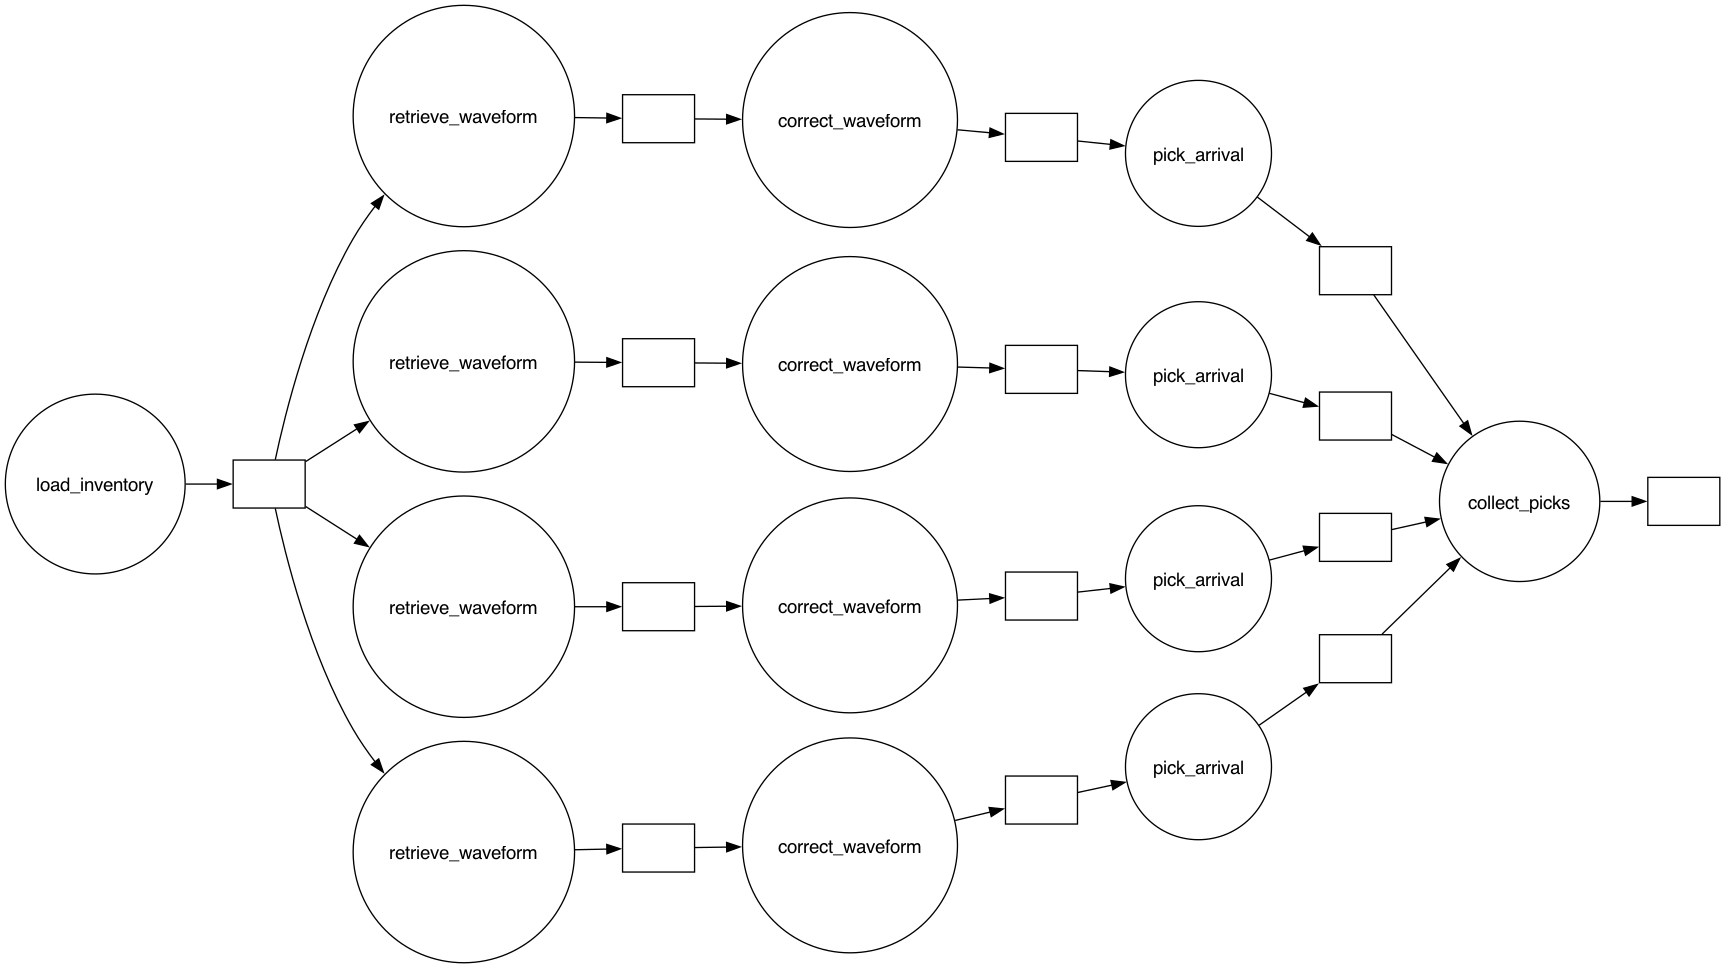

In [7]:
# -- 1. Create shared inventory task --

# Wrap load_inventory() with delayed()
# At this point, Dask does NOT run the function
# Instead, it creates a task describing what should be done later
# The resulting inventory_task will be shared by all station-specific waveform retrieval tasks.
inventory_task = delayed(load_inventory)(stations)

# -- 2. Create one processing branch for each seismic station --

pick_tasks = []
# Loop through the station names defined earlier
for station in stations:

    # Task to retrieve waveform
    # depends on inventory_task
    # the station inventory must be loaded before (dask knows this)
    waveform_task = delayed(retrieve_waveform)(station, inventory_task)

    # Task to correct waveform
    # depends on waveform_task
    corrected_task = delayed(correct_waveform)(waveform_task)

    # Task to pick arrival time
    # depends on corrected_task
    pick_task = delayed(pick_arrival)(corrected_task)

    # Save the final task
    # Each station produces its own pick_task
    # Because the station branches do not depend on one another
    # dask can potentially process several stations in parallel
    pick_tasks.append(pick_task)

# -- 3. Combine the results from all stations --

# Because collect_picks() receives the complete list of pick tasks
# it will run only after every station-specific branch has finished
workflow = delayed(collect_picks)(pick_tasks)

# -- 4. Visualize task graph --

# Display the workflow as a Directed Acyclic Graph (DAG)
# rankdir="LR" arranges the graph from left to right
workflow.visualize(rankdir="LR")

The graph shows one shared inventory task followed by several independent station-processing branches. Within each branch, waveform retrieval, correction, and arrival picking must occur sequentially. However, the separate station branches can be processed in parallel because they do not depend on one another.

This example serves as an analog of seismic workflows in cloud environments, where tasks such as waveform retrieval and preprocessing for multiple stations can be executed independently — a classic case of what's known as an **embarrassingly parallel** problem. In such problems, individual tasks require little to no communication with one another, making them ideal candidates for concurrent execution across distributed computing resources. In the context of seismology, each station's data can be fetched, corrected, and processed in isolation before being merged downstream for higher-level analysis. By leveraging cloud-based parallelization frameworks like Dask, we can significantly reduce total computation time through intelligent task scheduling and resource allocation.

### **3. DASK array (chunking)**

Dask array represents a large, potentially out-of-core, multi-dimensional array composed of many smaller `numpy` arrays (called ***chunks***) arranged in a grid.

The `dask.array` module is a powerful tool for handling large, multi-dimensional arrays that don't fit in memory, by breaking them into smaller pieces (called chunks) that are processed in parallel. Conceptually, it extends the familiar `numpy` API, allowing scientists and engineers to work with big data as if they were working with in-memory arrays — all while abstracting away the complexity of parallelization and memory management.

Think of a Dask array as a grid of many small `numpy` arrays, seamlessly stitched together. But unlike NumPy, where operations happen immediately, Dask builds a **lazy execution graph**: it constructs a task graph first, and only executes the computation when explicitly told to.

**Key features of dask array:**
- **Lazy evaluation:** All operations (e.g., +, mean, slicing) construct a task graph first. This avoids unnecessary intermediate results and optimizes performance.
- **Chunkwise operations:** Dask processes one chunk at a time using familiar NumPy-style syntax, enabling computations on datasets much larger than memory.
- **Scalable execution:** The same code can run on your laptop or scale to a multi-node cluster without modification — perfect for both prototyping and production workloads.

<img src="https://docs.dask.org/en/stable/_images/dask-array.svg" alt="DASK_array" width="550"/> 

Scientific datasets are often stored as large multidimensional arrays. Examples include seismic waveforms organized by station and time, satellite images, climate grids, and three-dimensional geophysical models. When an array becomes too large to fit comfortably in memory, processing it as a single NumPy array may become difficult or impossible.`dask.array` addresses this problem by dividing a large array into smaller pieces called **chunks**. Each chunk behaves like a NumPy array and can be processed independently. Dask coordinates these chunk-level calculations and combines the partial results to produce the final output.

In the following example, we will:

1. Create a two-dimensional Dask Array.
2. Divide the array into manageable chunks.
3. apply a simple mathematical operation.
4. Use `.compute()` to execute the task graph and return the result.

In [ ]:
import dask.array as da

x = da.zeros((1000, 1000), chunks=(100, 100)) # modify chunk size to compare

# Apply a simple operation: add 5 to each element
y = x + 5  # This builds a task graph, but does not execute anything yet

y

dask.array<add, shape=(1000, 1000), dtype=float64, chunksize=(100, 100), chunktype=numpy.ndarray>

Here we create a 1000&times;1000 Dask array split into 100&times;100 **chunks**, so the array is represented as a 10&times;10 grid of smaller NumPy blocks rather than one large array in memory. Adding `5` to it (`y = x + 5`) does not compute anything. It records the operation in a **task graph**, one task per chunk. Displaying `y` shows the array's shape, chunk layout, and data type alongside the graph that will produce it. Try changing the `chunks` argument to see how the number of tasks changes.

In [15]:
# Take the mean (also lazy, still no computation)
result = y.mean()

# Trigger the actual computation across all chunks and cores
result.compute()

5.0

Calling compute() tells Dask to:

1. Create and process the individual chunks.
2. Add 5 to the values in each chunk.
3. Calculate a partial result for each chunk.
4. Combine the partial results into the final mean.

### **4. Dask dataframe (partitioning)**

Dask dataframe is a large table of data composed of many smaller `pandas` DataFrames (partitions), split along the index.

A Dask DataFrame allows you to work with tabular data that is too large to fit into memory by dividing it into many smaller `pandas` DataFrame partitions, each of which is processed in parallel. If you're already comfortable using `pandas`, transitioning to `dask.dataframe` is relatively smooth — it implements a large subset of the familiar Pandas API and behavior.

Imagine having 100 GB of CSV files. Loading all of that into memory with Pandas would crash most machines. Dask sidesteps this limitation by lazily loading and operating on partitioned data, one chunk at a time, allowing you to analyze enormous datasets even on a laptop.

**Key features of dask dataframe:**
- **Pandas-compatible interface:** Uses similar syntax for filtering, grouping, and aggregating data.
- **Lazy evaluation:** Operations are not executed until .compute() is explicitly called.
- **Parallel execution:** Each partition is processed independently, enabling significant speed-ups on multi-core machines or clusters.
- **Out-of-core computation:** Easily handles data that exceeds available RAM by streaming in partitions as needed.

<img src="https://docs.dask.org/en/stable/_images/dask-dataframe.svg" alt="DASK_array" width="400"/> 

In [6]:
import pandas as pd

# Create a small example dataset
# using a random-number generator with a fixed seed
rng = np.random.default_rng(42)

# Define how many seismic observations will be included.
n_observations = 200_000

# Create a pandas DataFrame representing measurements collected from four seismic stations
# Each row represents one observation and contains:
#   - station: station identifier
#   - peak_amplitude: maximum waveform amplitude
#   - snr_db: signal-to-noise ratio measured in decibels
station_data = pd.DataFrame({"station": rng.choice(
        ["STA01", "STA02", "STA03", "STA04"],
        size=n_observations
    ),

    "peak_amplitude": rng.lognormal(mean=0.0, sigma=0.8, size=n_observations),

    "snr_db": rng.normal(loc=6.0, scale=3.0, size=n_observations)
})

station_data

,station,peak_amplitude,snr_db
0,STA01,2.343558,11.035674
1,STA04,0.351853,6.168342
2,STA03,1.562461,5.276518
3,STA02,1.007599,6.092468
4,STA02,6.650617,4.042879
...,...,...,...
199995,STA03,1.580389,4.325777
199996,STA02,0.623621,8.987534
199997,STA01,0.925031,3.225689
199998,STA04,2.994562,4.964203


This cell builds a synthetic dataset of 200,000 seismic observations using a seeded random-number generator, so the results are reproducible. Each row records one measurement from one of four stations, with a `peak_amplitude` drawn from a log-normal distribution and a `snr_db` (signal-to-noise ratio) drawn from a normal distribution. This is an ordinary in-memory **pandas** DataFrame, the starting point that we convert into a partitioned Dask DataFrame in the next cell.

In [7]:
import dask.dataframe as dd

# Convert the pandas DataFrame into a Dask DataFrame
station_ddf = dd.from_pandas(station_data, npartitions=8)

station_ddf

,station,peak_amplitude,snr_db
npartitions=8,,,
0,string,float64,float64
25000,...,...,...
...,...,...,...
175000,...,...,...
199999,...,...,...


Each partition is a pandas DataFrame containing a portion of the complete dataset. Dask can process these partitions independently,allowing several partitions to be handled in parallel.

This example begins with a pandas DataFrame so that it can run quickly in the notebook. In a larger scientific workflow, the complete dataset might not fit in memory. Instead of first loading it with pandas, Dask can construct a partitioned DataFrame directly from a collection of files:
>
> ```python
> station_ddf = dd.read_csv("data/station-observations-*.csv")
> ```
>
or, preferably for many cloud-based analytical workflows:
>
> ```python
> station_ddf = dd.read_parquet("data/station-observations/")
> ```

Dask initially reads only the dataset metadata. Individual partitions are loaded and processed when a result is requested with `.compute()` or`.persist()`.

### **4. Dask delayed (building workflows)**

Dask Array and Dask DataFrame are designed for structured numerical and tabular data. However, many scientific workflows consist of custom Python functions that
retrieve data, apply corrections, calculate measurements, and combine results. These workflows may not fit naturally into an array or DataFrame.

**Dask Delayed** allows us to parallelize these custom workflows with minimal changes to the original Python code. Wrapping a function with `delayed()` changes when the function is executed:

- A normal Python function executes immediately and returns its result.
- A delayed function does not execute immediately. It returns a delayed task describing what should be calculated later.

Earlier in this notebook, we used Dask Delayed to construct and visualize a simplified seismic-processing workflow. We will now execute that workflow and compare it with the equivalent serial approach.

In [8]:
import time

# =================================
# ---------- Serial Run -----------
# =================================

# -- 1. record the starting time --
serial_start = time.perf_counter()

# -- 2. loading and processing steps --
inventory = load_inventory(stations)
serial_picks = []
for station in stations:

    # Retrieve the waveform for the current station.
    waveform = retrieve_waveform(station, inventory)

    # Correct the retrieved waveform.
    corrected_waveform = correct_waveform(waveform)

    # Pick the arrival time from the corrected waveform.
    arrival_pick = pick_arrival(corrected_waveform)

    # Save the station name and its arrival time.
    serial_picks.append(arrival_pick)


# Combine the station results into a dictionary.
serial_result = collect_picks(serial_picks)

# Calculate the total serial execution time.
serial_runtime = time.perf_counter() - serial_start

print(f"\nSerial runtime: {serial_runtime:.2f} seconds")


# =================================
# --------- Parallel Run ----------
# =================================

# -- 1. Record the starting time --
parallel_start = time.perf_counter()

# -- 2. Execute processing workflow constructed earlier using delayed() --
parallel_result = workflow.compute()

# Calculate the total Dask execution time.
parallel_runtime = time.perf_counter() - parallel_start

print(f"\nDask runtime: {parallel_runtime:.2f} seconds")



Serial runtime: 1.42 seconds

Dask runtime: 0.52 seconds


In the serial workflow, the stations are processed one after another. Python completes waveform retrieval, correction, and arrival picking for one station before beginning the next station. In the Dask workflow, the processing steps within an individual station branch remain sequential because each step depends on the result of the previous one. However, the branches representing different stations are independent and can therefore be assigned to different Dask workers.

The amount of speedup depends on several factors, including:

- the number of available workers;
- the number of independent tasks;
- the duration of each task;
- scheduling and communication overhead; and
- whether data must be transferred between workers.

> **Important:** Dask does not guarantee that every workflow will run faster.
> Small or highly sequential workflows may take longer with Dask because
> scheduling tasks also requires time. Performance should be evaluated using a
> representative portion of the real scientific workflow.

### **5. DASK futures (dynamic processing)**

Dask Delayed is useful when we can describe the complete workflow before execution begins. In some scientific applications, however, we may want to submit tasks immediately, monitor their progress, or process individual result as soon as they become available.

Dask **Futures** provide this more interactive style of execution. A Future is a Python object representing a task that may be waiting, running, completed, or failed on a Dask worker.

<u>Unlike Delayed tasks, Futures use **eager execution**</u>

- `delayed()` builds a lazy task graph that waits for `.compute()`.

whereas

- `client.submit()` sends an individual task to the scheduler immediately.
- `client.map()` submits the same function for many inputs.
- `client.gather()` retrieves a collection of completed results.
- `as_completed()` returns results one at a time as they finish.

Futures are especially useful for dynamic workflows, real-time processing, and tasks whose completion times differ. In the following example, we will submit one processing task for each seismic station and inspect the results as they become available.

In [3]:
# Record the starting time.
futures_start = time.perf_counter()

# -- 1. Submit the shared inventory task --

# submit() sends one task to the scheduler immediately and returns a Future.
inventory_future = client.submit(load_inventory, stations)

# -- 2. Submit one processing branch per station --

# For each station we chain three dependent tasks: retrieve -> correct -> pick.
# Passing one Future as the input to the next submit() lets the scheduler track
# the dependency; passing inventory_future makes every branch wait for the shared
# inventory before its waveform is retrieved.
station_futures = []
for station in stations:
    waveform_future  = client.submit(retrieve_waveform, station, inventory_future)
    corrected_future = client.submit(correct_waveform, waveform_future)
    pick_future      = client.submit(pick_arrival, corrected_future)

    # Store the final Future for this station so we can monitor and collect it later.
    station_futures.append(pick_future)

# Display the Futures. Their status may be "pending", "running", or "finished",
# depending on how quickly the workers complete the tasks.
station_futures

[<Future: pending, key: pick_arrival-d2805fbaf35af6618547d715cf84c72d>,
 <Future: pending, key: pick_arrival-5f367ef55d128384805c1120a9b3b8b9>,
 <Future: pending, key: pick_arrival-76567b014d286dbea7fbfe2e4237db99>,
 <Future: pending, key: pick_arrival-bf713beb548c2eacd12b64551f8cb641>]

Unlike Dask Delayed, which builds the whole graph first and waits for `.compute()`, `client.submit()` sends each task to the scheduler **immediately** and returns a `Future` right away. Then the workers begin computing in the background while this cell finishes. Each `Future` is a handle to a result that may still be `pending`, `running`, or already `finished`; we store them in `station_futures` so we can monitor them and gather the results as they complete. This eager, submit-as-you-go style is what makes Futures well suited to dynamic workflows where later tasks depend on results that are not known ahead of time.

In [4]:
# Each Future contains a unique task key and its current execution status.
for future in station_futures:
    print(f"Task: {future.key}")
    print(f"Status: {future.status}")
    print()

Task: pick_arrival-d2805fbaf35af6618547d715cf84c72d
Status: finished

Task: pick_arrival-5f367ef55d128384805c1120a9b3b8b9
Status: finished

Task: pick_arrival-76567b014d286dbea7fbfe2e4237db99
Status: finished

Task: pick_arrival-bf713beb548c2eacd12b64551f8cb641
Status: finished



Now that the tasks are running, we collect their results. Because the station branches finish at slightly different times, we use `as_completed()` to process each result **the moment its task finishes**, rather than waiting for the whole batch.

In [6]:
from dask.distributed import as_completed

# -- 3. Collect results as they finish, using as_completed() --

# as_completed() yields each Future the moment its task completes, so results
# arrive in completion order rather than in the original station order.
picks = {}
for finished in as_completed(station_futures):
    station, pick_time = finished.result()   # .result() returns the computed value
    picks[station] = pick_time
    print(f"{station}: arrival pick at {pick_time:.2f} s")

futures_end = time.perf_counter()
print(f"\nFutures workflow finished in {futures_end - futures_start:.2f} s")

STA01: arrival pick at 7.23 s
STA02: arrival pick at 3.24 s
STA03: arrival pick at 0.25 s
STA04: arrival pick at 1.28 s

Futures workflow finished in 39.48 s


`as_completed()` is one of several ways to retrieve results. Two others mentioned above are worth demonstrating:

- `client.gather()` blocks until **every** Future is done and returns all results together &mdash; use it when you simply need the whole collection.
- `client.map()` submits the **same function across many inputs in a single call** &mdash; a concise alternative to the submit loop when the inputs are independent.

In [7]:
# --- client.gather(): collect every result at once ---
all_picks = dict(client.gather(station_futures))
print("gather() returned all results together:")
print(all_picks)

# --- client.map(): submit one function across many inputs in a single call ---
# Here it launches waveform retrieval for every station at once (one call, four
# tasks). The same inventory_future is broadcast to each call as the dependency.
waveform_futures = client.map(
    retrieve_waveform, stations, [inventory_future] * len(stations)
)
print("\nmap() returned one Future per station:")
print(waveform_futures)

gather() returned all results together:
{'STA01': np.float64(7.23), 'STA02': np.float64(3.24), 'STA03': np.float64(0.25), 'STA04': np.float64(1.28)}

map() returned one Future per station:
[<Future: pending, key: retrieve_waveform-4326be2a24d4c3f404b1385f4d0ac232>, <Future: pending, key: retrieve_waveform-bed4e7a7c5232c40e19d3e3b408c88db>, <Future: pending, key: retrieve_waveform-326c67805d2143551a7c6ec9181185b6>, <Future: pending, key: retrieve_waveform-dd61cd10ff9beaf767c164dadabec285>]


Calling `client.submit()` immediately sent the inventory task and the station-processing tasks to the Dask scheduler. Each station task received the inventory Future as a dependency, so Dask waited for the inventory to become available before processing the corresponding station.

After the shared inventory task finished, the independent station tasks could run concurrently on the available workers. The `as_completed()` iterator returned each result as soon as its station task finished. Consequently, the completion order was not required to match the original order of the station list.

The notebook remained available while the tasks were running. We could inspect the Futures, submit additional work, or respond to completed results without first constructing and computing one complete task graph.

| Dask Delayed | Dask Futures |
|---|---|
| Uses lazy execution | Uses eager execution |
| Builds the workflow before execution | Submits tasks immediately |
| Executes when `.compute()` is called | Executes through an active `Client` |
| Best for fixed dependency graphs | Best for dynamic or interactive workflows |
| Usually returns the final combined result | Can provide individual results as they finish |

Both interfaces use the same Dask scheduler and workers. The main difference is how and when tasks are submitted.

### **7. Compute vs Persist (Controlling Execution)**

Dask collections use **lazy evaluation**. Creating an array, filtering a DataFrame, or defining a calculation builds a task graph, but the calculation does not begin immediately. Two important methods for starting that calculation are `compute()` and `persist()`.

Although both methods execute a task graph, they return and store results differently:

- **`compute()`** evaluates the graph and returns the final result to the notebook as a regular Python, NumPy, or pandas object.
- **`persist()`** evaluates the graph but keeps the partitioned result in memory across the Dask workers. It returns another Dask collection connected to those stored partitions.

Use `compute()` when the final result is small enough to fit comfortably in the notebook's memory. Use `persist()` when an intermediate dataset will be reused by several downstream calculations.

In [9]:
# Build a lazy intermediate dataset

quality_controlled = station_ddf[station_ddf["snr_db"] >= 3.0]

print(type(quality_controlled))
print(f"Number of partitions:"f"{quality_controlled.npartitions}")
quality_controlled

<class 'dask.dataframe.dask_expr._collection.DataFrame'>
Number of partitions:8


,station,peak_amplitude,snr_db
npartitions=8,,,
0,string,float64,float64
25000,...,...,...
...,...,...,...
175000,...,...,...
199999,...,...,...


At this point, `quality_controlled` does not contain fully calculated results. It represents the original partitions together with instructions for applying the signal-to-noise filter.

#### Use `compute()`

In [10]:
# This is another lazy operation. 
# Dask adds the groupby and mean calculations to the existing task graph.
mean_amplitude = (quality_controlled
    .groupby("station")["peak_amplitude"]
    .mean()
)
# Calling compute() triggers the complete task graph:
mean_result = mean_amplitude.compute()

print(type(mean_result))

mean_result

<class 'pandas.core.series.Series'>


station
STA01    1.382208
STA02    1.379587
STA03    1.381743
STA04    1.384600
Name: peak_amplitude, dtype: float64

The station-level summary is small, so returning it to the notebook with `compute()` is appropriate. However, calling `compute()` on the complete quality-controlled dataset would bring every filtered row into the notebook's memory. For a very large dataset, that could exhaust the available memory.

#### Use `persist()`

In [13]:
from dask.distributed import wait

# persist() returns immediately with another Dask DataFrame. The
# calculation may still be running in the background.
quality_persisted = quality_controlled.persist()

# Wait until all persisted partitions have finished calculating.
wait(quality_persisted)

print("The quality-controlled partitions are now stored on the workers.")
quality_persisted

The quality-controlled partitions are now stored on the workers.


,station,peak_amplitude,snr_db
npartitions=8,,,
0,string,float64,float64
25000,...,...,...
...,...,...,...
175000,...,...,...
199999,...,...,...


`quality_persisted` remains a Dask DataFrame. Unlike the original lazy
collection, however, its filtered partitions have now been calculated and
stored in distributed worker memory. Downstream calculations can reuse these partitions without repeating the quality-control filter.

| Method | Where is the result stored? | Returned object | Best use |
|---|---|---|---|
| `compute()` | Notebook or client process | NumPy, pandas, or Python object | Retrieving a small final result |
| `persist()` | Distributed worker memory | Dask collection | Reusing an intermediate dataset |
| `dask.compute(a, b)` | Final results return to the notebook | Multiple concrete results | Computing related outputs together |